In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/prepinstaprime/europe-bike-store-sales/Sales.csv


# import libraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Reading dataset

In [42]:
data = pd.read_csv("/kaggle/input/datasets/prepinstaprime/europe-bike-store-sales/Sales.csv")
df = data.copy()
df

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113031,2016-04-12,12,April,2016,41,Adults (35-64),M,United Kingdom,England,Clothing,Vests,"Classic Vest, S",3,24,64,112,72,184
113032,2014-04-02,2,April,2014,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113033,2016-04-02,2,April,2016,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113034,2014-03-04,4,March,2014,37,Adults (35-64),F,France,Seine (Paris),Clothing,Vests,"Classic Vest, L",24,24,64,684,576,1260


# EDA (Exploratry Data Analysis)

# Data Shape

In [5]:
df.shape

(113036, 18)

In [6]:
print(f"number of rows in datast = {df.shape[0]}")
print(f"number of columns in datast = {df.shape[1]}")

number of rows in datast = 113036
number of columns in datast = 18


# Information about data

In [7]:
print("Information about data:\n")
df.info()

Information about data:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Date              113036 non-null  object
 1   Day               113036 non-null  int64 
 2   Month             113036 non-null  object
 3   Year              113036 non-null  int64 
 4   Customer_Age      113036 non-null  int64 
 5   Age_Group         113036 non-null  object
 6   Customer_Gender   113036 non-null  object
 7   Country           113036 non-null  object
 8   State             113036 non-null  object
 9   Product_Category  113036 non-null  object
 10  Sub_Category      113036 non-null  object
 11  Product           113036 non-null  object
 12  Order_Quantity    113036 non-null  int64 
 13  Unit_Cost         113036 non-null  int64 
 14  Unit_Price        113036 non-null  int64 
 15  Profit            113036 non-null  int64 
 16  Cost         

# describtion about data

In [8]:
df.describe()

,Day,Year,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
count,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000
mean,15.665753,2014.401739,35.919212,11.901660,267.296366,452.938427,285.051665,469.318695,754.370360
std,8.781567,1.272510,11.021936,9.561857,549.835483,922.071219,453.887443,884.866118,1309.094674
min,1.000000,2011.000000,17.000000,1.000000,1.000000,2.000000,-30.000000,1.000000,2.000000
25%,8.000000,2013.000000,28.000000,2.000000,2.000000,5.000000,29.000000,28.000000,63.000000
50%,16.000000,2014.000000,35.000000,10.000000,9.000000,24.000000,101.000000,108.000000,223.000000
75%,23.000000,2016.000000,43.000000,20.000000,42.000000,70.000000,358.000000,432.000000,800.000000
max,31.000000,2016.000000,87.000000,32.000000,2171.000000,3578.000000,15096.000000,42978.000000,58074.000000


# Check Missing Values

In [9]:
df.isna().sum()

Date                0
Day                 0
Month               0
Year                0
Customer_Age        0
Age_Group           0
Customer_Gender     0
Country             0
State               0
Product_Category    0
Sub_Category        0
Product             0
Order_Quantity      0
Unit_Cost           0
Unit_Price          0
Profit              0
Cost                0
Revenue             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(1000)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

# Sample Of Data

In [13]:
print("Data Sample : \n")
df.sample()

Data Sample : 



,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
66311,2011-01-24,24,January,2011,42,Adults (35-64),F,Australia,Victoria,Bikes,Road Bikes,"Road-750 Black, 48",1,344,540,83,344,427


In [14]:
df['Profit_Margin']= (df['Profit'] / df['Revenue']) *100 

In [15]:
df["Country"].value_counts()

Country
United States     38840
Australia         23736
Canada            14027
United Kingdom    13486
Germany           11027
France            10920
Name: count, dtype: int64

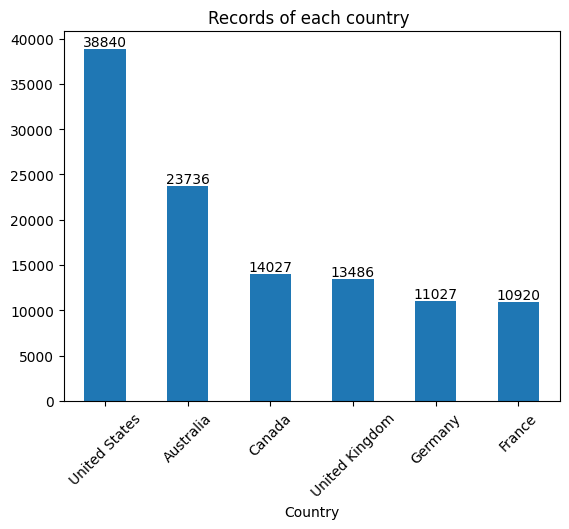

In [16]:
x=df["Country"].value_counts().plot(kind="bar")
plt.xticks(rotation = 45)
plt.title("Records of each country ")
for container in x.containers:
    x.bar_label(container)
plt.show()    

In [17]:
df["Product_Category"].value_counts()

Product_Category
Accessories    69312
Bikes          25794
Clothing       16930
Name: count, dtype: int64

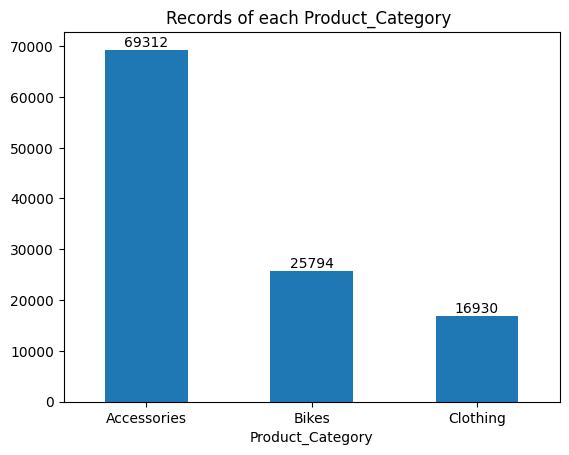

In [18]:
x=df["Product_Category"].value_counts().plot(kind="bar")
plt.xticks(rotation = 360)
plt.title("Records of each Product_Category ")
for container in x.containers:
    x.bar_label(container)
plt.show()    

In [19]:
df["Sub_Category"].value_counts()

Sub_Category
Tires and Tubes      33298
Bottles and Cages    15649
Road Bikes           13313
Helmets              12150
Mountain Bikes        8803
Jerseys               6006
Caps                  4358
Fenders               4032
Touring Bikes         3678
Gloves                2686
Cleaners              1802
Shorts                1794
Hydration Packs       1334
Socks                 1122
Vests                  964
Bike Racks             592
Bike Stands            455
Name: count, dtype: int64

In [20]:
df["Year"].value_counts()

Year
2016    29128
2014    29122
2015    24227
2013    24224
2011     2671
2012     2664
Name: count, dtype: int64

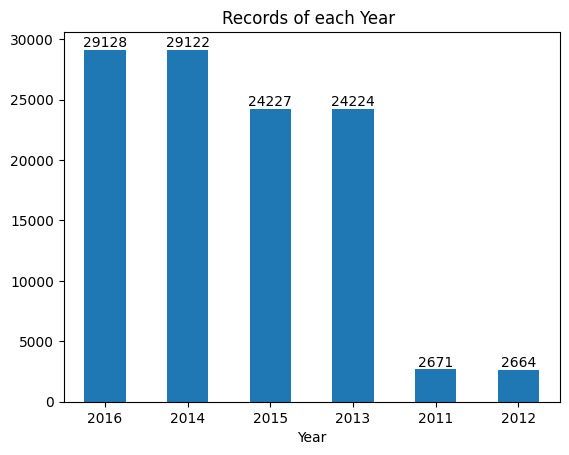

In [21]:
x=df["Year"].value_counts().plot(kind="bar")
plt.xticks(rotation = 360)
plt.title("Records of each Year ")
for container in x.containers:
    x.bar_label(container)
plt.show()    

In [22]:
df.sample()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue,Profit_Margin
27138,2014-03-23,23,March,2014,20,Youth (<25),M,Canada,British Columbia,Clothing,Gloves,"Half-Finger Gloves, S",14,9,24,207,126,333,62.162162


# Total Sales

In [23]:
print("total sales = ",df['Revenue'].sum())

total sales =  84826772


# Average sales

In [24]:
print("averge sales = ",df['Revenue'].mean())

averge sales =  757.1385269020672


# Total Profit

In [25]:
print("total Profit = ",df['Profit'].sum())

total Profit =  32046239


# Total sales per Year

In [54]:
Year_rev=df.groupby('Year')['Revenue'].sum().sort_values(ascending=False).reset_index()
Year_rev

,Year,Revenue
0,2015,20023991
1,2016,17713385
2,2013,15240037
3,2014,14152724
4,2012,9175983
5,2011,8964888


In [55]:
fig_Year_rev=px.bar(Year_rev,x="Year",y="Revenue",text_auto=True,title="Total sales per Year")
fig_Year_rev.show()

In [86]:
fig_Year_rev=px.line(Year_rev,x="Year",y="Revenue",markers=True,title="Total sales per Year")
fig_Year_rev.show()

# Total sales per month

In [26]:
month_rev=df.groupby('Month')['Revenue'].sum().sort_values(ascending=False).reset_index()
month_rev

,Month,Revenue
0,December,9046323
1,June,8978817
2,May,8789287
3,April,7568874
4,March,7306140
5,January,6961166
6,February,6805834
7,November,6206951
8,October,5956276
9,September,5822197


In [27]:
fig_month_rev = px.bar(month_rev,x="Month",y="Revenue",text_auto =True, title='Total Revenue by Month')
fig_month_rev.show()

# Total sales by Age_group

In [28]:
Age_Group_revenue = df.groupby('Age_Group')['Revenue'].sum().sort_values(ascending=False).reset_index()
Age_Group_revenue

,Age_Group,Revenue
0,Adults (35-64),42367181
1,Young Adults (25-34),30467032
2,Youth (<25),11685489
3,Seniors (64+),307070


In [29]:
fig_Age_Group_revenue = px.bar(Age_Group_revenue,x="Age_Group",y="Revenue",text_auto=True, title='Total Revenue by Age_Group')
fig_Age_Group_revenue.show()

# Total sales by Customer_Gender

In [30]:
Gender_revenue = df.groupby('Customer_Gender')['Revenue'].sum().sort_values(ascending=False).reset_index()
Gender_revenue

,Customer_Gender,Revenue
0,M,43132083
1,F,41694689


In [31]:
fig_Gender_revenue = px.pie(Gender_revenue, names='Customer_Gender', values='Revenue', title='Percentage of Total Revenue by Gender')
fig_Gender_revenue.show()

# Total sales by Country

In [32]:
Country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).reset_index()
Country_revenue

,Country,Revenue
0,United States,27777098
1,Australia,21196395
2,United Kingdom,10575628
3,Germany,8956724
4,France,8414745
5,Canada,7906182


In [33]:
fig_Country_revenue = px.bar(Country_revenue,x="Country",y="Revenue",text_auto=True, title='Total Revenue by Country')
fig_Country_revenue.show()

# Top10 State by Total sales  

In [34]:
State_revenue = df.groupby('State')['Revenue'].sum().sort_values(ascending=False).reset_index().head(10)
State_revenue

,State,Revenue
0,California,17529787
1,England,10575628
2,New South Wales,9125980
3,British Columbia,7848334
4,Washington,6701258
5,Queensland,5055843
6,Victoria,5038294
7,Oregon,3435046
8,Hessen,2067980
9,Saarland,2026497


In [35]:
fig_State_revenue = px.bar(State_revenue,x="State",y="Revenue",text_auto=True, title='Top10 State by Total sales')
fig_State_revenue.show()

# 

# Total Sales by each Product_Category

In [36]:
Product_Category_revenue = df.groupby('Product_Category')['Revenue'].sum().sort_values(ascending=False).reset_index()
Product_Category_revenue

,Product_Category,Revenue
0,Bikes,61434484
1,Accessories,15022766
2,Clothing,8369522


In [37]:
fig_Product_Category_revenue = px.bar(Product_Category_revenue,x="Product_Category",y="Revenue",text_auto=True, title='Total Sales by each Product_Category')
fig_Product_Category_revenue.show()

# Total Sales by each Sub_Category

In [38]:
Sub_Category_revenue = df.groupby('Sub_Category')['Revenue'].sum().sort_values(ascending=False).reset_index()
Sub_Category_revenue

,Sub_Category,Revenue
0,Road Bikes,33150708
1,Mountain Bikes,21020794
2,Touring Bikes,7262982
3,Helmets,5738482
4,Tires and Tubes,4598124
5,Jerseys,4112382
6,Shorts,1740710
7,Bottles and Cages,1390570
8,Fenders,1245733
9,Hydration Packs,990406


In [39]:
fig_Sub_Category_revenue=px.bar(Sub_Category_revenue,x="Sub_Category",y="Revenue",text_auto=True,title='Total Sales by each Sub_Category')
fig_Sub_Category_revenue.show()

In [40]:
df.sample()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue,Profit_Margin
66482,2013-12-02,2,December,2013,59,Adults (35-64),M,France,Seine (Paris),Bikes,Road Bikes,"Road-750 Black, 48",1,344,540,99,344,443,22.34763


# Top 10 Products by Total Revenue,profit

In [57]:
product_revenue = df.groupby('Product')[['Revenue','Profit']].sum().sort_values(by="Profit",ascending=False).head(10).reset_index()
product_revenue

,Product,Revenue,Profit
0,"Mountain-200 Black, 38",3366248,1310464
1,"Road-150 Red, 62",3829416,1243755
2,"Mountain-200 Silver, 42",3081078,1231452
3,"Sport-100 Helmet, Red",2019021,1191402
4,"Mountain-200 Silver, 38",3035442,1165560
5,"Sport-100 Helmet, Black",1948695,1141330
6,"Mountain-200 Black, 46",2769620,1080672
7,"Road-150 Red, 52",3180840,1053260
8,"Sport-100 Helmet, Blue",1775081,1048446
9,"Mountain-200 Black, 42",2641606,1036542


In [59]:
fig_product_revenue=px.bar(product_revenue,x="Product",y=["Revenue","Profit"],barmode="group",text_auto=True,title="Top 10 Products by Total Revenue,profit")
fig_product_revenue.show()

# Top 10 Products by Total Order_Quantity

In [50]:
product_quantity = df.groupby('Product')['Order_Quantity'].sum().sort_values(ascending=False).head(10).reset_index()
product_quantity

,Product,Order_Quantity
0,Water Bottle - 30 oz.,164086
1,Patch Kit/8 Patches,157583
2,Mountain Tire Tube,102792
3,AWC Logo Cap,67316
4,"Sport-100 Helmet, Red",63663
5,Road Tire Tube,62296
6,Fender Set - Mountain,62118
7,"Sport-100 Helmet, Black",62105
8,Touring Tire Tube,56802
9,"Sport-100 Helmet, Blue",55895


In [51]:
fig_product_quantity = px.bar(product_quantity,x="Product",y="Order_Quantity",text_auto=True,title="Top 10 Products by Total Order_Quantity")
fig_product_quantity.show()

# top products sold by each Customer_Gender

In [78]:
gender_category = df.groupby(['Customer_Gender','Product_Category'])['Revenue'].sum().sort_values(ascending=False).unstack()
gender_category

Product_Category,Accessories,Bikes,Clothing
Customer_Gender,,,
F,7092647,30982518,3860434
M,8025345,30799616,4510448


In [52]:
df.sample()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
38616,2013-09-21,21,September,2013,57,Adults (35-64),M,Australia,New South Wales,Accessories,Helmets,"Sport-100 Helmet, Blue",8,13,35,140,104,244


# coorelation between profit column , numerical columns

In [81]:
corr =df[["Profit","Customer_Age","Order_Quantity"]].corr()
corr

,Profit,Customer_Age,Order_Quantity
Profit,1.000000,0.004319,-0.238863
Customer_Age,0.004319,1.000000,0.026887
Order_Quantity,-0.238863,0.026887,1.000000


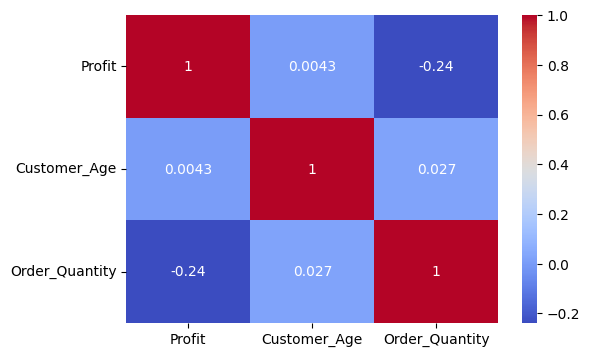

In [82]:
plt.figure(figsize=(6,4))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.show()

In [90]:
df.to_excel("Cleaned_Bank_Data.xlsx", index=False)